 请按要求编写一个汽车租赁系统。     
 需要实现的要求：       
 汽车类     
 a. 车型分类：经济车型（EconomyCar）、豪华车（LuxuryCar）、跑车（SportCar）、SUV（SUV）     
 b. 车辆通用属性：品牌（brand）、星号（model）、车牌（platenum）、每天租金（dayrent）、车辆编号（carid）        
 c. 车辆通用方法：      
 get_brand() -- 获取品牌              
get_model() -- 获取型号     
get_platenum() -- 获取车牌      
get_dayrent() -- 获取每天租金       
get_carid() -- 获取车辆编号     
calc_rent() -- 通过租赁天数和折扣计算一共需要多少租金       
d. 不同车型的特殊属性和方法：       
经济车型享有额外的补贴优惠      
豪华车需要增加保险费用      
跑车需要增加损耗费用        
SUV 如果租车时间大于 7 天，原有折扣的基础上再打 7 折        
业务类      
a. 属性：       
cars -- 字典类型，用于绑定车辆编号和相应的对象      
stocks -- 字典类型，用于存放每一种车型的库存        
b. 方法：       
operate() -- 程序入口，获取并分发指令       
register() -- 录入汽车      
get_stock() -- 获取库存     
rent_car() -- 租车服务      
return_car() -- 还车服务        
录入车辆演示：      
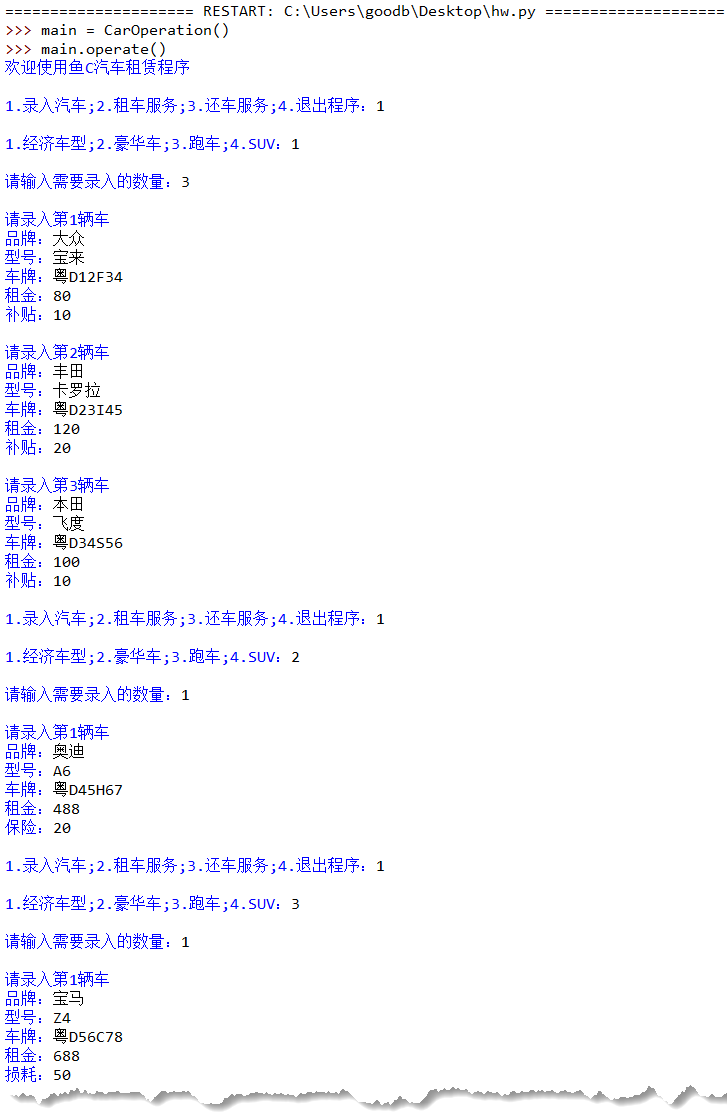
租车和还车演示（注意：租赁成功后会相应地减少库存，同样道理，还车成功后也要添加回库存）：        
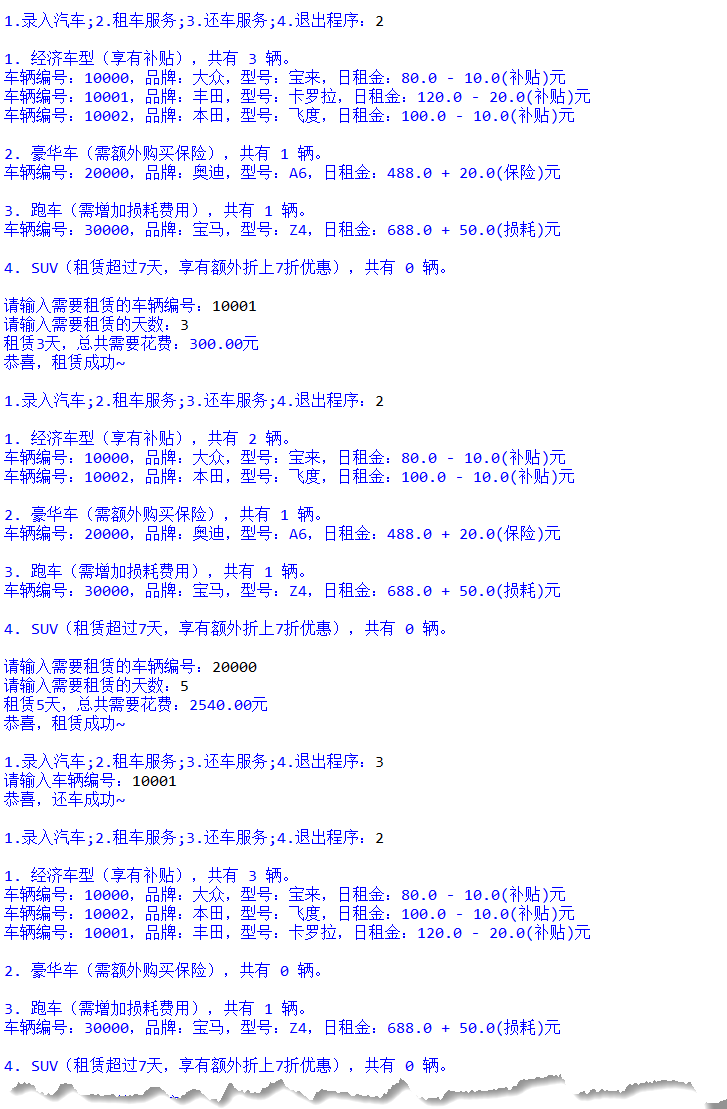

In [ ]:
class Cars:
    def __init__(self, brand, model, platenum, dayrent, carid):
        self.brand = brand
        self.model = model
        self.platenum = platenum
        self.dayrent = dayrent
        self.carid = carid
    
    def get_brand(self):
        return self.brand
    
    def get_model(self):
        return self.model
    
    def get_platenum(self):
        return self.platenum
    
    def get_dayrent(self):
        return self.dayrent
    
    def get_carid(self):
        return self.carid
    
    def calc_rent(self,days,discount = 1.0):
        return self.dayrent * days * discount

class EconomyCar(Cars):
    def __init__(self, brand, model, platenum, dayrent, carid):
        super().__init__(brand, model, platenum, dayrent, carid)
        self.subsidy = 0.0
    
    def calc_rent(self,days,discount = 1.0):
        base_rent = super().calc_rent(days, discount)
        return base_rent - self.subsidy * days
    
class LuxuryCar(Cars):
    def __init__(self, brand, model, platenum, dayrent, carid):
        super().__init__(brand, model, platenum, dayrent, carid)
        self.insurance = 0.0

    def calc_rent(self, days, discount=1.0):
        base_rent = super().calc_rent(days, discount)
        return self.insurance * days + base_rent
    
class SportCar(Cars):
    def __init__(self, brand, model, platenum, dayrent, carid):
        super().__init__(brand, model, platenum, dayrent, carid)
        self.loss = 0.0

    def calc_rent(self, days, discount=1.0):
        base_rent = super().calc_rent(days, discount)
        return self.loss * days + base_rent
    
class SUV(Cars):
    def __init__(self, brand, model, platenum, dayrent, carid):
        super().__init__(brand, model, platenum, dayrent, carid)
    
    def calc_rent(self, days, discount=1.0):
        base_rent = super().calc_rent(days, discount)
        if days <= 7:
            return base_rent
        else:
            return base_rent * 0.7

class CarOperation:
    def __init__(self):
        self.cars = {}
        self.stocks = {"EconomyCar":[], "LuxuryCar":[], "SportCar":[], "SUV":[]}
        self.next_carid = {"EconomyCar":10000, "LuxuryCar":20000, "SportCar":30000, "SUV":40000}
        self.car_rented = {}

    def operate(self):
        while True:
            print("欢迎使用鱼C汽车租赁程序~")
            choice = input("1.录入汽车;2.租车服务;3.还车服务;4.退出程序：")
            if choice == "1":
                self.add_car()
            elif choice == "2":
                self.rent_car()
            elif choice == "3":
                self.return_car()
            elif choice == "4":
                print("谢谢使用！")
                break
            else:
                print("无效的选择！")
    
    def add_car(self):
        car_type = input("1.经济车型;2.豪华车;3.跑车;4.SUV：")
        if car_type == "1":
            self.add_economy_car()
        elif car_type == "2":
            self.add_luxury_car()
        elif car_type == "3":
            self.add_sport_car()
        elif car_type == "4":
            self.add_suv_car()
        else:
            print("无效的汽车类型！")
    
    def add_economy_car(self):
        car_count = int(input("请输入需要录入的数量："))
        num = 1
        while num <= car_count:
            print(f"请录入第{num}辆车")
            brand = input("品牌：")
            model = input("型号：")
            platenum = input("车牌：")
            dayrent = float(input("租金："))
            subsidy = float(input("补贴："))
            car = EconomyCar(brand, model, platenum, dayrent, self.next_carid["EconomyCar"])
            car.subsidy = subsidy
            self.cars[car.carid] = car
            self.stocks["EconomyCar"].append(car.carid)
            self.next_carid["EconomyCar"] += 1
            print(f"第{num}辆车的录入成功！")
            print(f"车辆编号: {car.carid}")
            num += 1

    def add_luxury_car(self):
        car_count = int(input("请输入需要录入的数量："))
        num = 1
        while num <= car_count:
            print(f"请录入第{num}辆车")
            brand = input("品牌：")
            model = input("型号：")
            platenum = input("车牌：")
            dayrent = float(input("租金："))
            insurance = float(input("保险："))
            car = LuxuryCar(brand, model, platenum, dayrent, self.next_carid["LuxuryCar"])
            car.insurance = insurance
            self.cars[car.carid] = car
            self.stocks["LuxuryCar"].append(car.carid)
            self.next_carid["LuxuryCar"] += 1
            print(f"第{num}辆车的录入成功！")
            print(f"车辆编号: {car.carid}")
            num += 1

    def add_sport_car(self):
        car_count = int(input("请输入需要录入的数量："))
        num = 1
        while num <= car_count:
            print(f"请录入第{num}辆车")
            brand = input("品牌：")
            model = input("型号：")
            platenum = input("车牌：")
            dayrent = float(input("租金："))
            loss = float(input("损耗："))
            car = SportCar(brand, model, platenum, dayrent, self.next_carid["SportCar"])
            car.loss = loss
            self.cars[car.carid] = car
            self.stocks["SportCar"].append(car.carid)
            self.next_carid["SportCar"] += 1
            print(f"第{num}辆车的录入成功！")
            print(f"车辆编号: {car.carid}")
            num += 1

    def add_suv_car(self):
        car_count = int(input("请输入需要录入的数量："))
        num = 1
        while num <= car_count:
            print(f"请录入第{num}辆车")
            brand = input("品牌：")
            model = input("型号：")
            platenum = input("车牌：")
            dayrent = float(input("租金："))
            car = SUV(brand, model, platenum, dayrent, self.next_carid["SUV"])
            self.cars[car.carid] = car
            self.stocks["SUV"].append(car.carid)
            self.next_carid["SUV"] += 1
            print(f"第{num}辆车的录入成功！")
            print(f"车辆编号: {car.carid}")
            num += 1

    def show_economy_cars(self):
        print(f"1. 经济车型（享有补贴），共有{len(self.stocks["EconomyCar"])}辆。")
        if self.stocks["EconomyCar"]:
            for carid in self.stocks["EconomyCar"]:
                print(f"车辆编号: {carid}，品牌：{self.cars[carid].brand}，型号：{self.cars[carid].model}，日租金：{self.cars[carid].dayrent} - {self.cars[carid].subsidy}（补贴）元")
        print("\n")

    def show_luxury_cars(self):
        print(f"2. 豪华车（需额外购买保险），共有{len(self.stocks["LuxuryCar"])}辆。")
        if self.stocks["LuxuryCar"]:
            for carid in self.stocks["LuxuryCar"]:
                print(f"车辆编号: {carid}，品牌：{self.cars[carid].brand}，型号：{self.cars[carid].model}，日租金：{self.cars[carid].dayrent} + {self.cars[carid].insurance}（保险）元")
        print("\n")

    def show_sport_cars(self):
        print(f"3. 跑车（需增加损耗费用），共有{len(self.stocks["SportCar"])}辆。")
        if self.stocks["SportCar"]:
            for carid in self.stocks["SportCar"]:
                print(f"车辆编号: {carid}，品牌：{self.cars[carid].brand}，型号：{self.cars[carid].model}，日租金：{self.cars[carid].dayrent} + {self.cars[carid].loss}（损耗）元")
        print("\n")
    
    def show_SUV_cars(self):
        print(f"4. SUV（租赁超过7天，享有额外7折优惠），共有{len(self.stocks["SUV"])}辆。")
        if self.stocks["SUV"]:
            for carid in self.stocks["SUV"]:
                print(f"车辆编号: {carid}，品牌：{self.cars[carid].brand}，型号：{self.cars[carid].model}，日租金：{self.cars[carid].dayrent}元")
        print("\n")

    def rent_car(self):
        self.show_economy_cars()
        self.show_luxury_cars()
        self.show_sport_cars()
        self.show_SUV_cars()
        rent_carid = int(input("请输入需要租赁的车辆编号："))
        if rent_carid not in self.cars.keys():
            print("车辆不存在！")
            return
        days = int(input("请输入需要租赁的天数："))
        if days <= 0:
            print("租赁天数必须大于0！")
            return
        print(f"租赁{days}天，总共需要花费{self.cars[rent_carid].calc_rent(days)}元")
        self.car_rented[rent_carid] = self.cars.pop(rent_carid)
        if 10000 <= rent_carid <= 19999:
            self.stocks["EconomyCar"].remove(rent_carid)
        elif 20000 <= rent_carid <= 29999:
            self.stocks["LuxuryCar"].remove(rent_carid)
        elif 30000 <= rent_carid <= 39999:
            self.stocks["SportCar"].remove(rent_carid)
        else:
            self.stocks["SUV"].remove(rent_carid)
        print("恭喜，租赁成功~")
    
    def return_car(self):
        return_carid = int(input("请输入车辆编号："))
        if return_carid not in self.car_rented.keys():
            print("车辆不存在！")
            return
        self.cars[return_carid] = self.car_rented.pop(return_carid)
        if 10000 <= return_carid <= 19999:
            self.stocks["EconomyCar"].append(return_carid)
        elif 20000 <= return_carid <= 29999:
            self.stocks["LuxuryCar"].append(return_carid)
        elif 30000 <= return_carid <= 39999:
            self.stocks["SportCar"].append(return_carid)
        else:
            self.stocks["SUV"].append(return_carid)
        print("恭喜，还车成功~")

main = CarOperation()
main.operate()